Dataset Shape: (19236948, 33)

First few rows:
shape: (5, 33)
┌────────────────┬─────────┬───────────┬─────────┬───┬───────────┬───────┬────────┬──────┐
│ time           ┆ pv_id   ┆ appr_temp ┆ ceiling ┆ … ┆ coord2    ┆ type  ┆ energy ┆ nins │
│ ---            ┆ ---     ┆ ---       ┆ ---     ┆   ┆ ---       ┆ ---   ┆ ---    ┆ ---  │
│ str            ┆ str     ┆ f64       ┆ f64     ┆   ┆ f64       ┆ str   ┆ f64    ┆ f64  │
╞════════════════╪═════════╪═══════════╪═════════╪═══╪═══════════╪═══════╪════════╪══════╡
│ 2024-08-01     ┆ PV_ID_0 ┆ null      ┆ null    ┆ … ┆ -0.172021 ┆ train ┆ null   ┆ 0.0  │
│ 00:05:00+09:00 ┆         ┆           ┆         ┆   ┆           ┆       ┆        ┆      │
│ 2024-08-01     ┆ PV_ID_0 ┆ null      ┆ null    ┆ … ┆ -0.172021 ┆ train ┆ null   ┆ 0.0  │
│ 00:10:00+09:00 ┆         ┆           ┆         ┆   ┆           ┆       ┆        ┆      │
│ 2024-08-01     ┆ PV_ID_0 ┆ null      ┆ null    ┆ … ┆ -0.172021 ┆ train ┆ 0.0    ┆ 0.0  │
│ 00:15:00+09:00 ┆         ┆

/var/folders/8k/l_bm1gs94r72gg6w58d8xc2m0000gn/T/ipykernel_80322/4017322476.py:33: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  numeric_df.hist(ax=axes, bins=20)


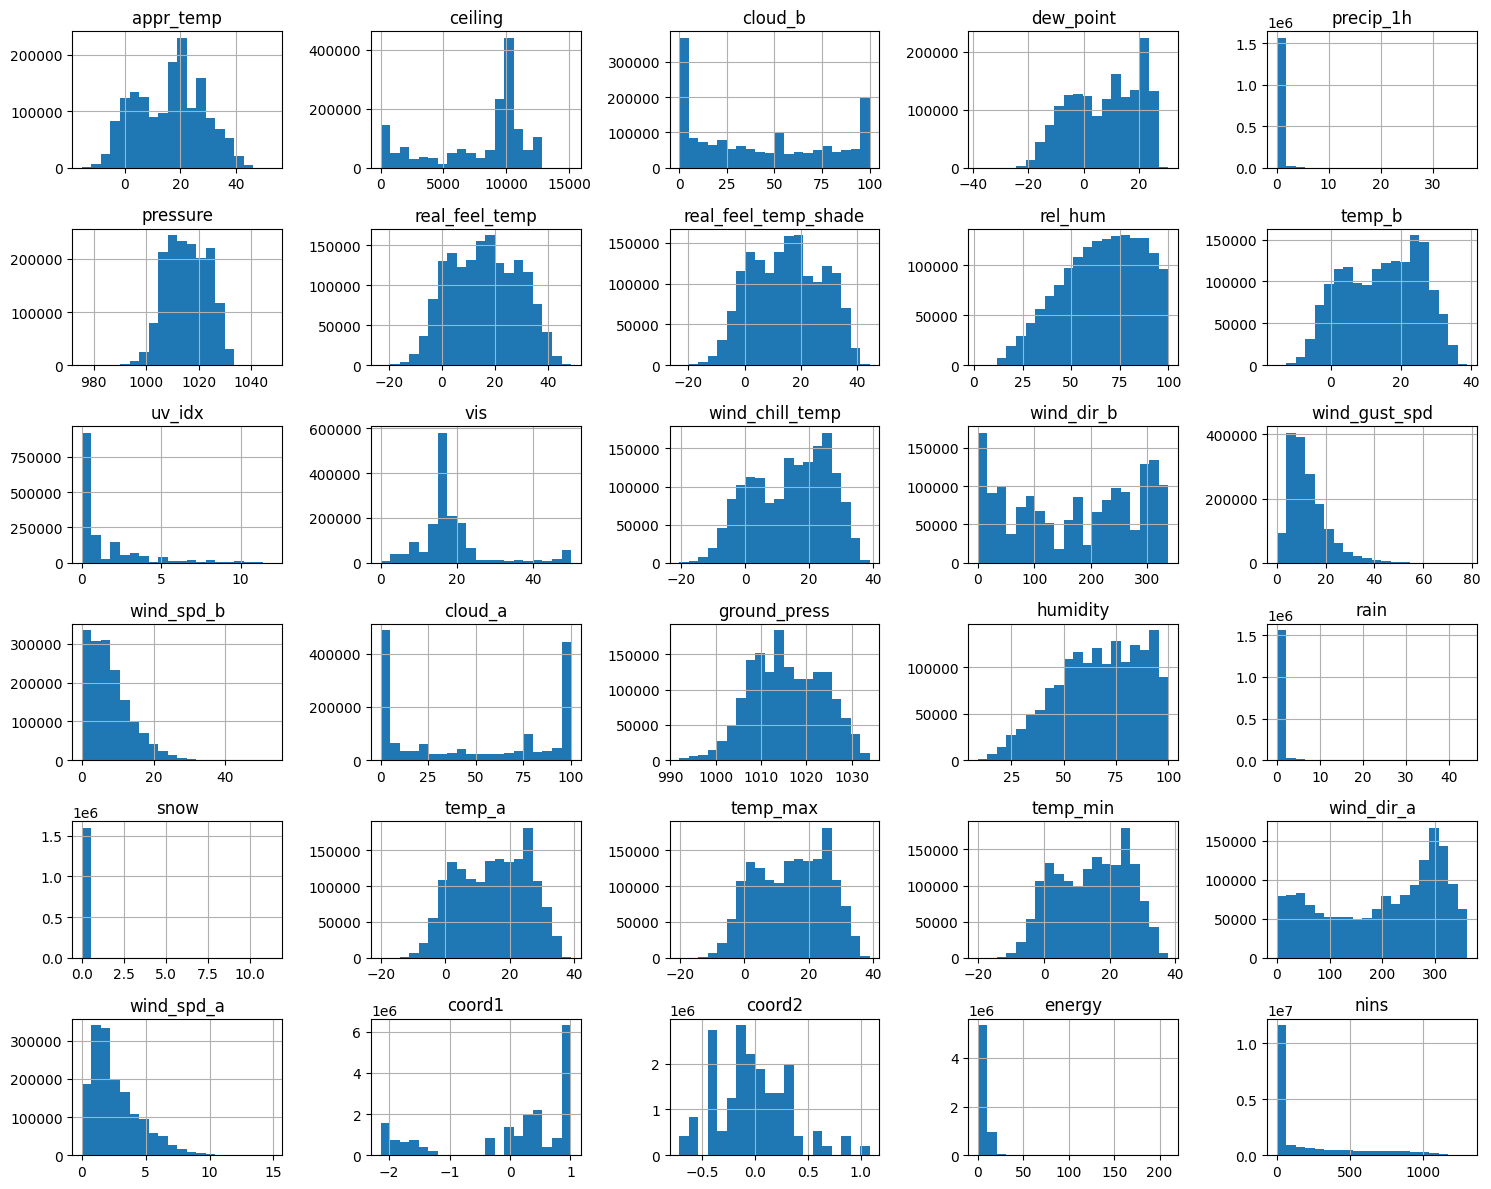

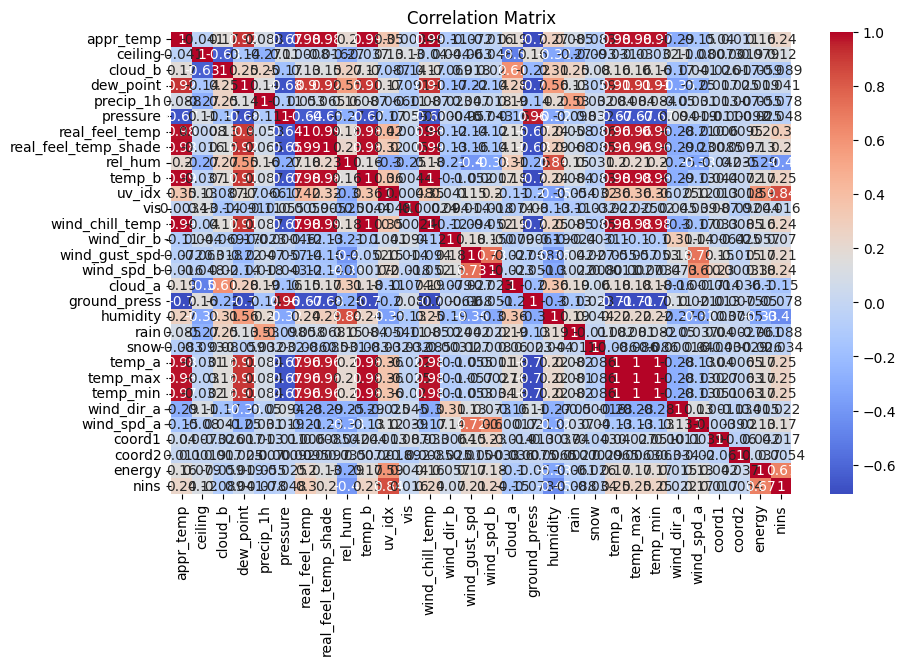

In [2]:
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Display settings
pl.Config.set_tbl_rows(100)

# Load data
df = pl.read_csv('./data/train.csv')

# Basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nData Info:")
print(df.schema)

print("\nBasic Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.null_count())

print("\nData Types:")
print(df.dtypes)

# Visualizations
# Distribution plots for numeric columns only
numeric_df = df.to_pandas().select_dtypes(include=[np.number])
fig, axes = plt.subplots(figsize=(15, 12))
numeric_df.hist(ax=axes, bins=20)
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.to_pandas().corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()
